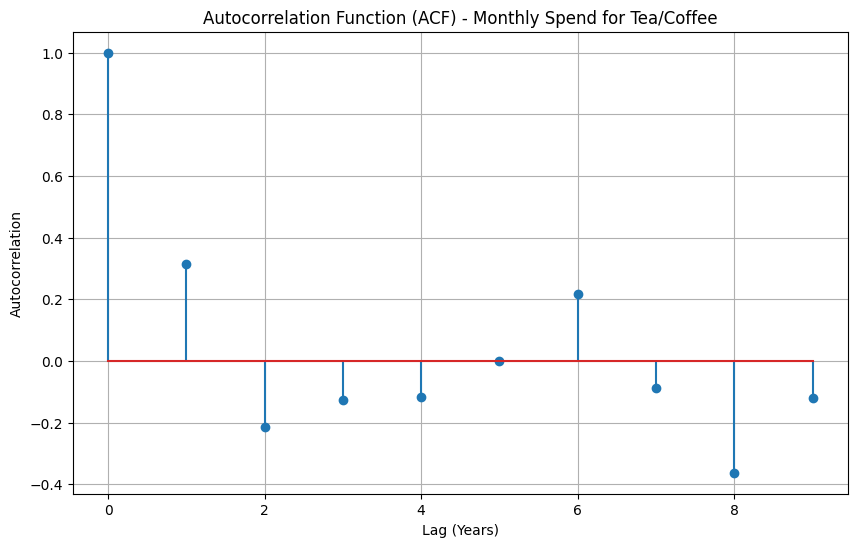

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/tea_vs_coffee_global_final.csv')

# Convert Year column
df['year'] = pd.to_datetime(df['year'], format='%Y', errors='coerce')

# Remove missing values
df = df.dropna(subset=['year', 'monthly_spend'])

# Group by year (important for time series)
yearly_sales = df.groupby('year')['monthly_spend'].sum()

# Convert to numpy array
data = yearly_sales.values

# Parameters
N = len(data)
lags = range(min(20, N))

autocorr_values = []

# Mean and Variance
mean_data = np.mean(data)
variance_data = np.var(data)

# ACF Calculation
for lag in lags:
    if lag == 0:
        autocorr_values.append(1)
    else:
        auto_cov = np.sum((data[:-lag] - mean_data) * (data[lag:] - mean_data)) / N
        autocorr_values.append(auto_cov / variance_data)

# Plot ACF
plt.figure(figsize=(10, 6))
plt.stem(lags, autocorr_values)

plt.title('Autocorrelation Function (ACF) - Monthly Spend for Tea/Coffee')
plt.xlabel('Lag (Years)')
plt.ylabel('Autocorrelation')

plt.grid(True)
plt.show()